<a href="https://colab.research.google.com/github/minyi-k03/Large-Language-Model-LLM-/blob/Fine-Tuning/openai_gpt4o_mini_vision_api_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OpenAI GPT-4o mini Vision API 기초 예제

## 작성자 : AISchool ( http://aischool.ai/%ec%98%a8%eb%9d%bc%ec%9d%b8-%ea%b0%95%ec%9d%98-%ec%b9%b4%ed%85%8c%ea%b3%a0%eb%a6%ac/ )

## GPT  Vision API Reference : https://platform.openai.com/docs/guides/vision

## GPT Vision API pricing : https://openai.com/api/pricing/

In [1]:
!pip install openai

In [2]:
!pip show openai

Name: openai
Version: 2.15.0
Summary: The official Python library for the openai API
Home-page: https://github.com/openai/openai-python
Author: 
Author-email: OpenAI <support@openai.com>
License: Apache-2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: anyio, distro, httpx, jiter, pydantic, sniffio, tqdm, typing-extensions
Required-by: 


## OpenAI API Key 설정

In [4]:
OPENAI_KEY = "Input Your Key"

 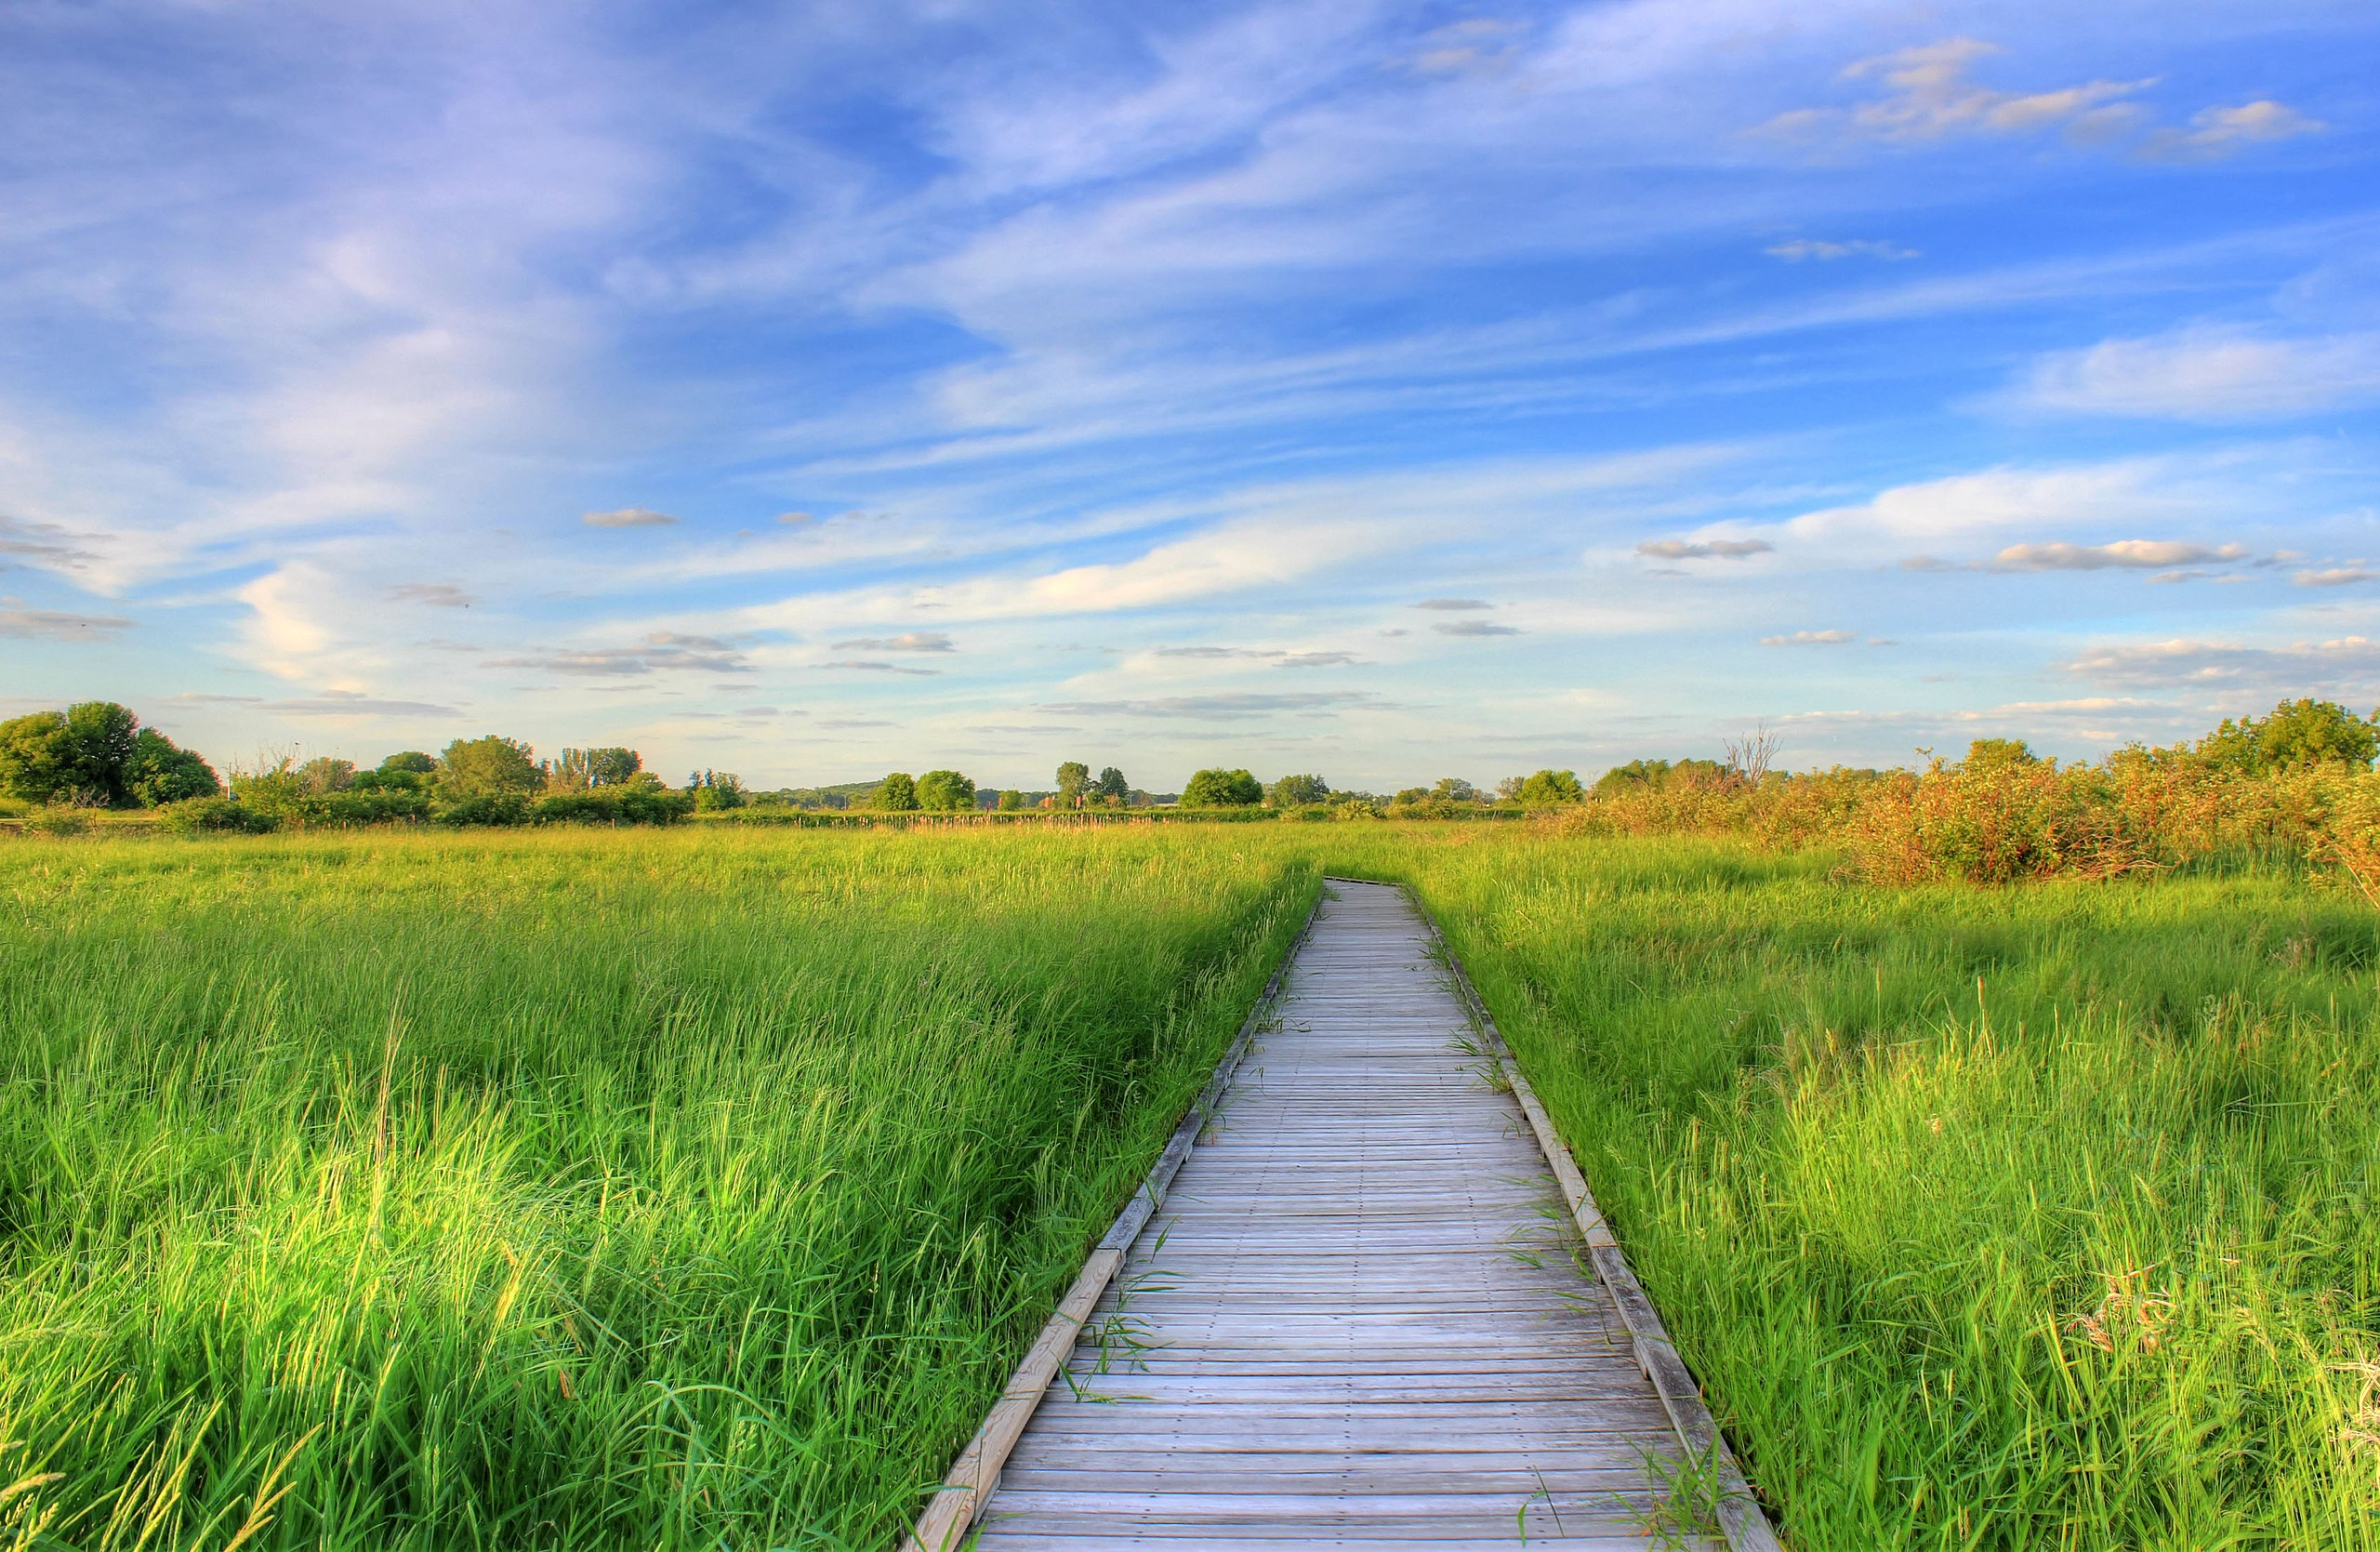


# Quick start

In [5]:
from openai import OpenAI

client = OpenAI(api_key=OPENAI_KEY)

# Uploading base 64 encoded images

위에 있는 테스트 이미지를 test_image.jpeg라는 파일명으로 저장 한뒤 colab 환경에 업로드를 진행합니다.

In [7]:
import base64
import requests

# Function to encode the image
def encode_image(image_path):
  with open(image_path, "rb") as image_file:
    return base64.b64encode(image_file.read()).decode('utf-8')

# Path to your image
image_path = "test_image.jpeg"

# Getting the base64 string
base64_image = encode_image(image_path)

headers = {
  "Content-Type": "application/json",
  "Authorization": f"Bearer {OPENAI_KEY}"
}

payload = {
  "model": "gpt-4o-mini",
  "messages": [
    {
      "role": "user",
      "content": [
        {
          "type": "text",
          "text": "이 이미지에는 무엇이 있나요?"
        },
        {
          "type": "image_url",
          "image_url": {
            "url": f"data:image/jpeg;base64,{base64_image}"
          }
        }
      ]
    }
  ],
  "max_tokens": 300
}

response = requests.post("https://api.openai.com/v1/chat/completions", headers=headers, json=payload)

print(response.json())

{'id': 'chatcmpl-D15GYAnf9yJ9VL8TPm5r7S5FZzavz', 'object': 'chat.completion', 'created': 1769150942, 'model': 'gpt-4o-mini-2024-07-18', 'choices': [{'index': 0, 'message': {'role': 'assistant', 'content': '이 이미지는 넓은 초원과 푸른 하늘을 배경으로 하는 풍경을 보여줍니다. 중앙에는 나무로 만든 산책로가 있어, 주변의 풀밭과 나무들 사이로 이어지고 있습니다. 하늘은 맑고 구름이 간간이 보입니다. 전체적으로 자연의 평화롭고 아름다운 모습이 느껴지는 장면입니다.', 'refusal': None, 'annotations': []}, 'logprobs': None, 'finish_reason': 'stop'}], 'usage': {'prompt_tokens': 36850, 'completion_tokens': 88, 'total_tokens': 36938, 'prompt_tokens_details': {'cached_tokens': 0, 'audio_tokens': 0}, 'completion_tokens_details': {'reasoning_tokens': 0, 'audio_tokens': 0, 'accepted_prediction_tokens': 0, 'rejected_prediction_tokens': 0}}, 'service_tier': 'default', 'system_fingerprint': 'fp_8bbc38b4db'}


In [8]:
#넘긴 이미지에 대한 해석
response.json()['choices'][0]['message']['content']

'이 이미지는 넓은 초원과 푸른 하늘을 배경으로 하는 풍경을 보여줍니다. 중앙에는 나무로 만든 산책로가 있어, 주변의 풀밭과 나무들 사이로 이어지고 있습니다. 하늘은 맑고 구름이 간간이 보입니다. 전체적으로 자연의 평화롭고 아름다운 모습이 느껴지는 장면입니다.'

# [시각정보 기반 질의응답] 데이터에 대한 테스트

## [시각정보 기반 질의응답] 데이터 다운로드 : https://www.aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&aihubDataSe=data&dataSetSn=104

In [ ]:
# 테스트용 이미지 2개 불러오기

# NIA_dataset02_000000777750.jpg
# NIA_dataset02_000000777856.jpg

## 테스트 이미지 2장 읽어오기

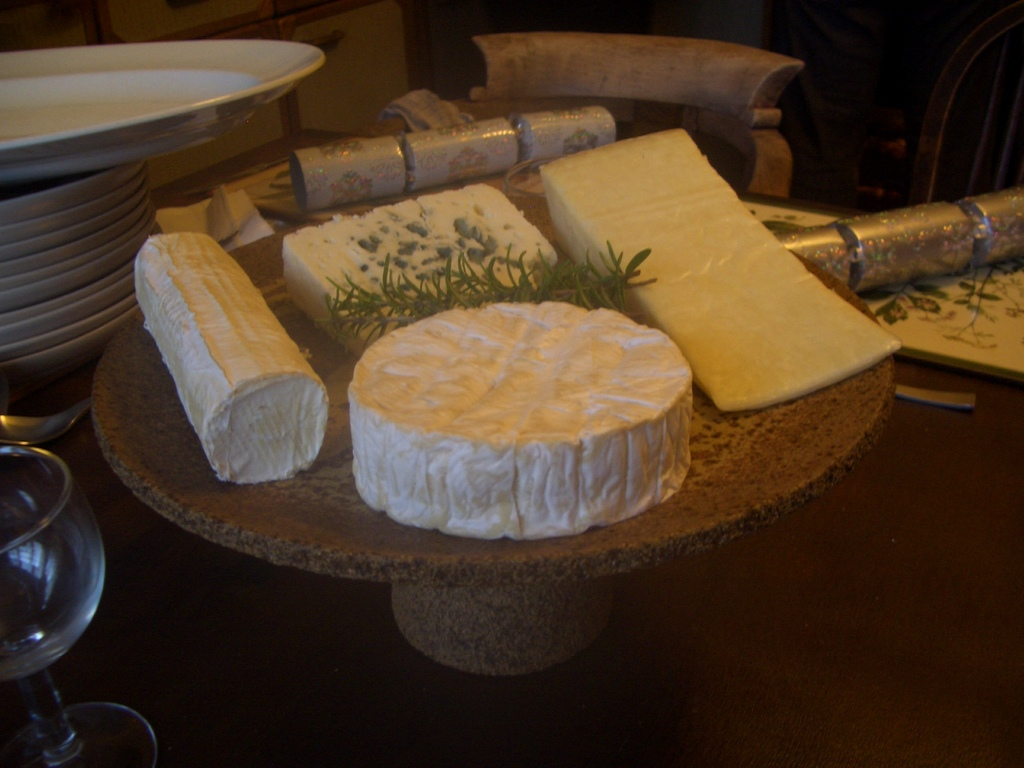

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

# 이미지 파일 경로
test_image_1_filename = "NIA_dataset02_000000777750.jpg"

# 이미지 읽기
test_image_1 = Image.open(test_image_1_filename)
test_image_1

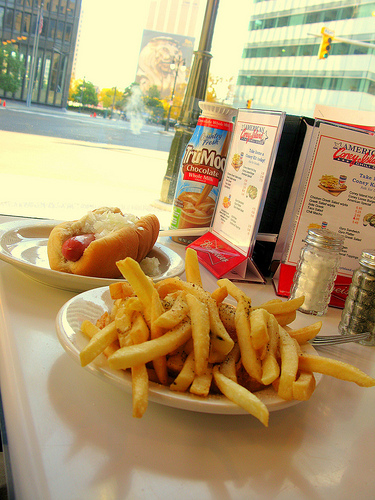

In [10]:
# 이미지 파일 경로
test_image_2_filename = "NIA_dataset02_000000777856.jpg"

# 이미지 읽기
test_image_2 = Image.open(test_image_2_filename)
test_image_2

## 레이블 json 파일들 읽어오기

In [13]:
import json

# JSON 파일 경로
images_json_filename = 'images.json'

# JSON 파일 읽기
with open(images_json_filename, 'r') as file:
    images_json_data = json.load(file)
images_json_data

{'info': {'year': '2020',
  'version': 'v1.0',
  'description': 'VQA 모델 트레이닝 데이터셋',
  'contributor': '유클리드소프트 연구소',
  'url': 'http://www.euclidsoft.co.kr',
  'date_created': '2020-12-24 10:00:00'},
 'data_type': '중',
 'data_subtype': 'train',
 'images': [{'image_id': '1-1',
   'image': 'NIA_dataset01_000000000001.jpg',
   'category': 'food'},
  {'image_id': '1-4',
   'image': 'NIA_dataset01_000000000004.jpg',
   'category': 'food'},
  {'image_id': '1-16',
   'image': 'NIA_dataset01_000000000016.jpg',
   'category': 'food'},
  {'image_id': '1-21',
   'image': 'NIA_dataset01_000000000021.jpg',
   'category': 'food'},
  {'image_id': '1-23',
   'image': 'NIA_dataset01_000000000023.jpg',
   'category': 'food'},
  {'image_id': '1-29',
   'image': 'NIA_dataset01_000000000029.jpg',
   'category': 'food'},
  {'image_id': '1-40',
   'image': 'NIA_dataset01_000000000040.jpg',
   'category': 'food'},
  {'image_id': '1-43',
   'image': 'NIA_dataset01_000000000043.jpg',
   'category': 'food'},
  {'i

In [14]:
def get_image_id_by_filename(data, image_filename):
    for image_info in data.get('images', []):
        if image_info.get('image') == image_filename:
            return image_info.get('image_id')
    return None

In [15]:
test_image_1_image_id = get_image_id_by_filename(images_json_data, test_image_1_filename)
test_image_1_image_id

'2-777750'

In [16]:
test_image_2_image_id = get_image_id_by_filename(images_json_data, test_image_2_filename)
test_image_2_image_id

'2-777856'

In [17]:
# JSON 파일 경로
question_json_filename = 'question.json'

# JSON 파일 읽기
with open(question_json_filename, 'r') as file:
    question_json_data = json.load(file)
question_json_data

{'info': {'year': '2020',
  'version': 'v1.0',
  'description': 'VQA 모델 트레이닝 데이터셋',
  'contributor': '유클리드소프트 연구소',
  'url': 'http://www.euclidsoft.co.kr',
  'date_created': '2020-12-24 10:00:00'},
 'data_type': '중',
 'data_subtype': 'train',
 'questions': [{'question_id': '1000',
   'image_id': '1-1',
   'question': '분홍색 통은 몇 개입니까?'},
  {'question_id': '1001', 'image_id': '1-1', 'question': '조리통은 무슨색입니까?'},
  {'question_id': '1002', 'image_id': '1-1', 'question': '녹색 물건은 무엇입니까?'},
  {'question_id': '4000', 'image_id': '1-4', 'question': '이것은 얼룩말입니까?'},
  {'question_id': '4001', 'image_id': '1-4', 'question': '동물은 무엇을 먹고 있습니까?'},
  {'question_id': '4002', 'image_id': '1-4', 'question': '어떤 동물인가요?'},
  {'question_id': '16000',
   'image_id': '1-16',
   'question': '케이크에는 몇 개의 층이 있습니까?'},
  {'question_id': '16001',
   'image_id': '1-16',
   'question': '이 케이크는 초콜릿처럼 보입니까?'},
  {'question_id': '16002',
   'image_id': '1-16',
   'question': '이 케이크를 몇 명이나 먹을 수 있습니까?'},
  {'question_id': '21

In [18]:
def get_questions_by_image_id(data, image_id):
    questions = [{'question_id': q['question_id'], 'question': q['question']} for q in data.get('questions', []) if q.get('image_id') == image_id]
    return questions

In [19]:
test_image_1_questions = get_questions_by_image_id(question_json_data, test_image_1_image_id)
test_image_1_questions

[{'question_id': '777750001', 'question': '접시에 담겨 있는 것은 무엇입니까?'},
 {'question_id': '777750002', 'question': '테이블 왼쪽에 접시가 쌓여 있습니까?'},
 {'question_id': '777750003', 'question': '접시 위에 녹색 야채는 무엇입니까?'},
 {'question_id': '777750004', 'question': '테이블 위에 유리잔이 있습니까?'},
 {'question_id': '777750005', 'question': '접시 위에 원형 치즈가 있습니까?'}]

In [20]:
test_image_2_questions = get_questions_by_image_id(question_json_data, test_image_2_image_id)
test_image_2_questions

[{'question_id': '777856001', 'question': '왼쪽 접시에 놓인 음식은 어떤 종류의 음식입니까?'},
 {'question_id': '777856002', 'question': '오른쪽 접시에 놓인 음식은 어떤 식재료로 만들었습니까?'},
 {'question_id': '777856003', 'question': '식탁 위에 놓인 접시의 색상은 무엇입니까?'},
 {'question_id': '777856004', 'question': '식탁 위에 몇 개의 병이 있습니까?'},
 {'question_id': '777856005', 'question': '왼쪽 접시에 놓인 음식 안에 무엇이 들어 있습니까?'},
 {'question_id': '799868001', 'question': '식탁에 놓인 음식은 몇 가지가 있나요?'},
 {'question_id': '799868002',
  'question': '식탁 위에 놓인 음식은 슬로우 푸드입니까, 패스트 푸드입니까?'},
 {'question_id': '799868003', 'question': '식탁 위에 놓인 양념통은 무엇이 담겨 있나요?'},
 {'question_id': '799868004', 'question': '식탁에 놓인 메뉴판은 어떻게 놓여 있나요?'},
 {'question_id': '799868005', 'question': '식탁에 놓인 음식은 열량이 높은 편인가요?'}]

In [21]:
# JSON 파일 경로
annotation_json_filename = 'annotation.json'

# JSON 파일 읽기
with open(annotation_json_filename, 'r') as file:
    annotation_json_data = json.load(file)
annotation_json_data

{'info': {'year': '2020',
  'version': 'v1.0',
  'description': 'VQA 모델 트레이닝 데이터셋',
  'contributor': '유클리드소프트 연구소',
  'url': 'http://www.euclidsoft.co.kr',
  'date_created': '2020-12-24 10:00:00'},
 'data_type': '중',
 'data_subtype': 'train',
 'annotations': [{'question_id': '1000',
   'image_id': '1-1',
   'multiple_choice_answer': '2',
   'answer_confidence': 'yes'},
  {'question_id': '1001',
   'image_id': '1-1',
   'multiple_choice_answer': '분홍색, 노란색',
   'answer_confidence': 'yes'},
  {'question_id': '1002',
   'image_id': '1-1',
   'multiple_choice_answer': '브로콜리',
   'answer_confidence': 'yes'},
  {'question_id': '4000',
   'image_id': '1-4',
   'multiple_choice_answer': '예',
   'answer_confidence': 'yes'},
  {'question_id': '4001',
   'image_id': '1-4',
   'multiple_choice_answer': '풀',
   'answer_confidence': 'yes'},
  {'question_id': '4002',
   'image_id': '1-4',
   'multiple_choice_answer': '얼룩말',
   'answer_confidence': 'yes'},
  {'question_id': '16000',
   'image_id': '1-1

In [22]:
def get_answer_by_question_id(data, question_id):
    for annotation in data.get('annotations', []):
        if annotation.get('question_id') == question_id:
            return {'question_id': annotation.get('question_id'), 'multiple_choice_answer': annotation.get('multiple_choice_answer')}
    return None

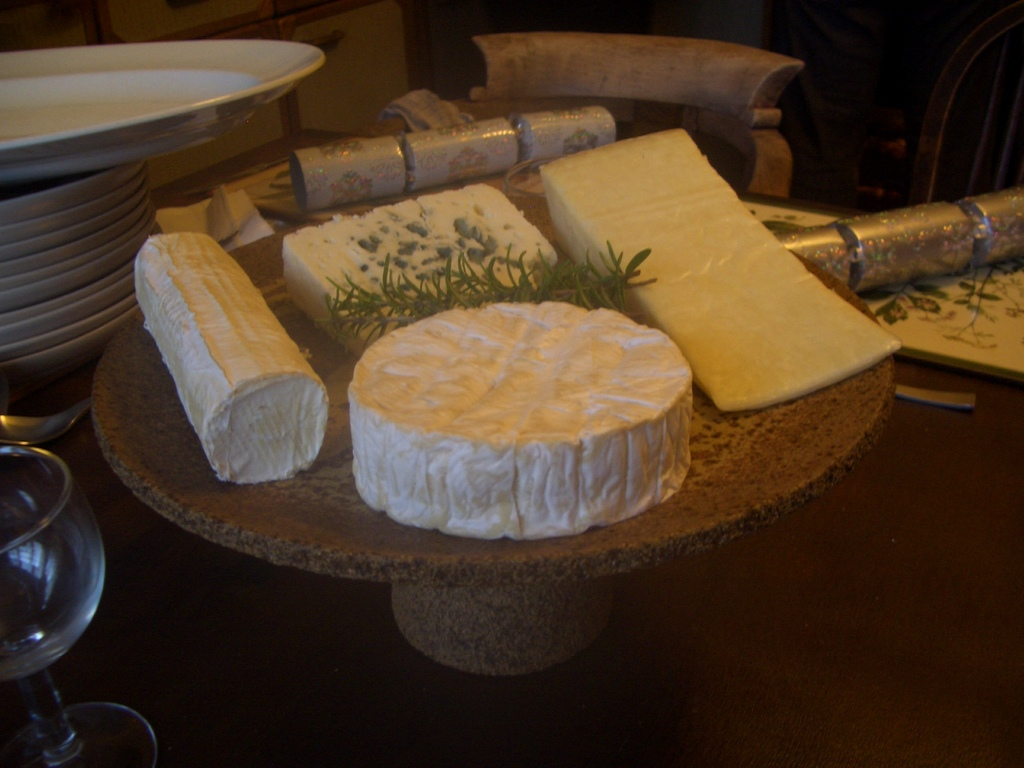

In [23]:
test_image_1

In [24]:
test_image_1_questions

[{'question_id': '777750001', 'question': '접시에 담겨 있는 것은 무엇입니까?'},
 {'question_id': '777750002', 'question': '테이블 왼쪽에 접시가 쌓여 있습니까?'},
 {'question_id': '777750003', 'question': '접시 위에 녹색 야채는 무엇입니까?'},
 {'question_id': '777750004', 'question': '테이블 위에 유리잔이 있습니까?'},
 {'question_id': '777750005', 'question': '접시 위에 원형 치즈가 있습니까?'}]

In [25]:
test_image_1_answer = get_answer_by_question_id(annotation_json_data, '777750001')
test_image_1_answer

{'question_id': '777750001', 'multiple_choice_answer': '치즈'}

In [26]:
test_image_1_answer = get_answer_by_question_id(annotation_json_data, '777750002')
test_image_1_answer

{'question_id': '777750002', 'multiple_choice_answer': '예'}

In [27]:
test_image_1_answer = get_answer_by_question_id(annotation_json_data, '777750003')
test_image_1_answer

{'question_id': '777750003', 'multiple_choice_answer': '애플민트'}

In [28]:
test_image_1_answer = get_answer_by_question_id(annotation_json_data, '777750004')
test_image_1_answer

{'question_id': '777750004', 'multiple_choice_answer': '예'}

In [29]:
test_image_1_answer = get_answer_by_question_id(annotation_json_data, '777750005')
test_image_1_answer

{'question_id': '777750005', 'multiple_choice_answer': '예'}

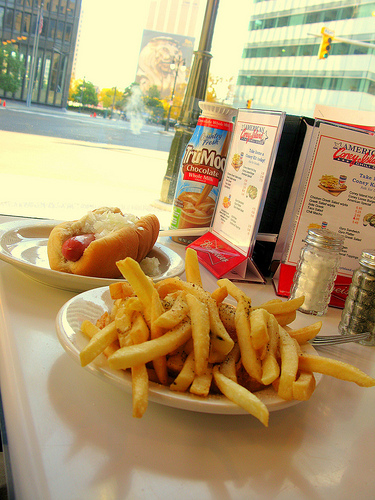

In [30]:
test_image_2

In [31]:
test_image_2_questions = get_questions_by_image_id(question_json_data, test_image_2_image_id)
test_image_2_questions

[{'question_id': '777856001', 'question': '왼쪽 접시에 놓인 음식은 어떤 종류의 음식입니까?'},
 {'question_id': '777856002', 'question': '오른쪽 접시에 놓인 음식은 어떤 식재료로 만들었습니까?'},
 {'question_id': '777856003', 'question': '식탁 위에 놓인 접시의 색상은 무엇입니까?'},
 {'question_id': '777856004', 'question': '식탁 위에 몇 개의 병이 있습니까?'},
 {'question_id': '777856005', 'question': '왼쪽 접시에 놓인 음식 안에 무엇이 들어 있습니까?'},
 {'question_id': '799868001', 'question': '식탁에 놓인 음식은 몇 가지가 있나요?'},
 {'question_id': '799868002',
  'question': '식탁 위에 놓인 음식은 슬로우 푸드입니까, 패스트 푸드입니까?'},
 {'question_id': '799868003', 'question': '식탁 위에 놓인 양념통은 무엇이 담겨 있나요?'},
 {'question_id': '799868004', 'question': '식탁에 놓인 메뉴판은 어떻게 놓여 있나요?'},
 {'question_id': '799868005', 'question': '식탁에 놓인 음식은 열량이 높은 편인가요?'}]

In [32]:
# 식탁 위에 놓인 음식은 슬로우 푸드입니까, 패스트 푸드입니까?
test_image_2_answer = get_answer_by_question_id(annotation_json_data, '799868002')
test_image_2_answer

{'question_id': '799868002', 'multiple_choice_answer': '패스트 푸드'}

In [33]:
# 식탁에 놓인 음식은 열량이 높은 편인가요?
test_image_2_answer = get_answer_by_question_id(annotation_json_data, '799868005')
test_image_2_answer

{'question_id': '799868005', 'multiple_choice_answer': '에'}

In [34]:
def get_gpt_response(image_filename, question):
    # Path to your image
    image_path = image_filename

    # Getting the base64 string
    base64_image = encode_image(image_path)

    headers = {
      "Content-Type": "application/json",
      "Authorization": f"Bearer {OPENAI_KEY}"
    }

    payload = {
      "model": "gpt-4o-mini",
      "messages": [
        {
          "role": "user",
          "content": [
            {
              "type": "text",
              "text": question
            },
            {
              "type": "image_url",
              "image_url": {
                "url": f"data:image/jpeg;base64,{base64_image}"
              }
            }
          ]
        }
      ],
      "max_tokens": 300
    }

    response = requests.post("https://api.openai.com/v1/chat/completions", headers=headers, json=payload)

    return response.json()['choices'][0]['message']['content']

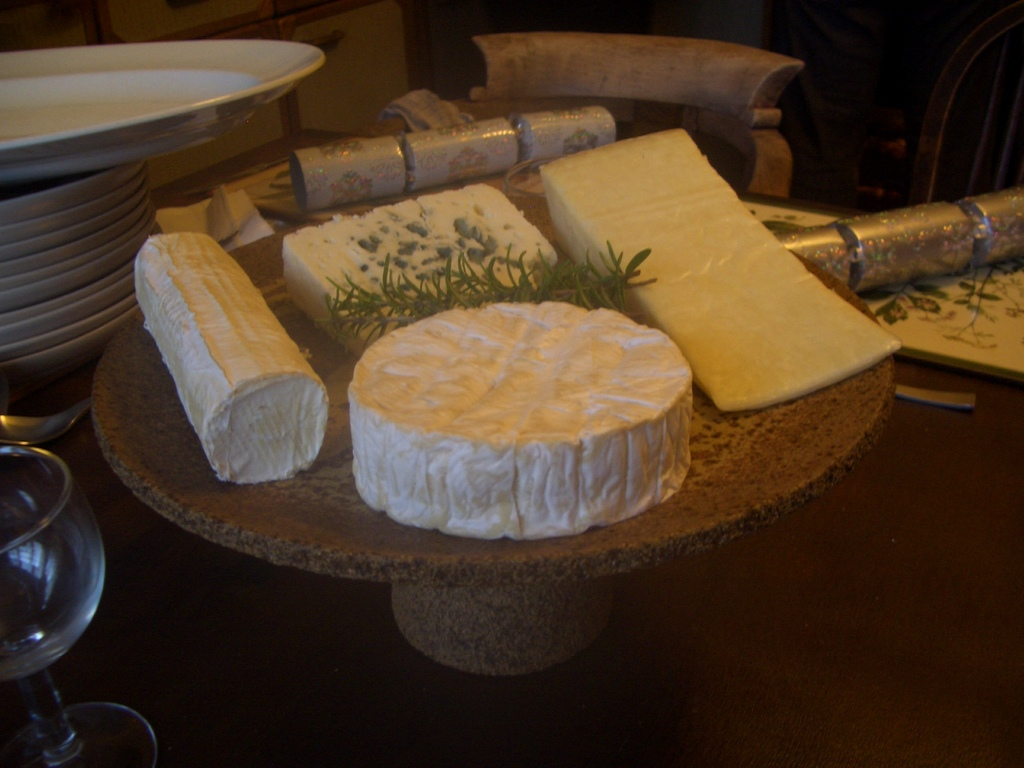

In [ ]:
test_image_1

In [35]:
test_image_1_questions

[{'question_id': '777750001', 'question': '접시에 담겨 있는 것은 무엇입니까?'},
 {'question_id': '777750002', 'question': '테이블 왼쪽에 접시가 쌓여 있습니까?'},
 {'question_id': '777750003', 'question': '접시 위에 녹색 야채는 무엇입니까?'},
 {'question_id': '777750004', 'question': '테이블 위에 유리잔이 있습니까?'},
 {'question_id': '777750005', 'question': '접시 위에 원형 치즈가 있습니까?'}]

In [ ]:
get_gpt_response(test_image_1_filename, '접시에 담겨 있는 것은 무엇입니까?')
# 정답 : '치즈'

'접시에 담겨 있는 것은 여러 종류의 치즈입니다. 다양한 모양과 색깔의 치즈가 포함되어 있으며, 그 중 일부는 허브로 장식되어 있습니다.'

In [37]:
get_gpt_response(test_image_1_filename, '테이블 왼쪽에 접시가 쌓여 있습니까?')
# 정답 : '예'

'네, 테이블 왼쪽에 접시가 쌓여 있습니다.'

In [38]:
get_gpt_response(test_image_1_filename, '접시 위에 녹색 야채는 무엇입니까?')
# 정답 : '애플민트'

'접시 위에 녹색 야채는 보이지 않으며, 대신 여러 종류의 치즈가 놓여 있습니다. 추가적으로 궁금한 점이 있으시면 말씀해 주세요!'

In [39]:
get_gpt_response(test_image_1_filename, '테이블 위에 유리잔이 있습니까?')
# 정답 : '예'

'네, 테이블 위에 유리잔이 있습니다.'

In [40]:
get_gpt_response(test_image_1_filename, '접시 위에 원형 치즈가 있습니까?')
# 정답 : '예'

'네, 접시 위에 원형 치즈가 있습니다.'

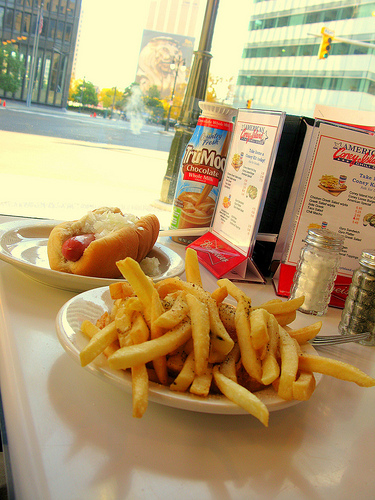

In [41]:
test_image_2

In [42]:
test_image_2_questions

[{'question_id': '777856001', 'question': '왼쪽 접시에 놓인 음식은 어떤 종류의 음식입니까?'},
 {'question_id': '777856002', 'question': '오른쪽 접시에 놓인 음식은 어떤 식재료로 만들었습니까?'},
 {'question_id': '777856003', 'question': '식탁 위에 놓인 접시의 색상은 무엇입니까?'},
 {'question_id': '777856004', 'question': '식탁 위에 몇 개의 병이 있습니까?'},
 {'question_id': '777856005', 'question': '왼쪽 접시에 놓인 음식 안에 무엇이 들어 있습니까?'},
 {'question_id': '799868001', 'question': '식탁에 놓인 음식은 몇 가지가 있나요?'},
 {'question_id': '799868002',
  'question': '식탁 위에 놓인 음식은 슬로우 푸드입니까, 패스트 푸드입니까?'},
 {'question_id': '799868003', 'question': '식탁 위에 놓인 양념통은 무엇이 담겨 있나요?'},
 {'question_id': '799868004', 'question': '식탁에 놓인 메뉴판은 어떻게 놓여 있나요?'},
 {'question_id': '799868005', 'question': '식탁에 놓인 음식은 열량이 높은 편인가요?'}]

In [43]:
get_gpt_response(test_image_2_filename, '식탁 위에 놓인 음식은 슬로우 푸드입니까, 패스트 푸드입니까?')
# 정답 : '패스트 푸드'

'식탁 위에 놓인 음식은 패스트 푸드입니다. 핫도그와 프렌치 프라이는 일반적으로 빠르게 제공되는 음식의 예시입니다.'

In [44]:
get_gpt_response(test_image_2_filename, '식탁에 놓인 음식은 열량이 높은 편인가요?')
# 정답 : '에'

'네, 식탁에 놓인 음식은 일반적으로 열량이 높은 편입니다. 핫도그와 감자튀김은 탄수화물, 지방, 그리고 추가적인 칼로리를 포함하고 있어, 전체적으로 높은 열량을 제공합니다. 이러한 음식은 종종 패스트푸드에 속하며, 칼로리가 많고 영양소는 상대적으로 적을 수 있습니다.'